# Prompted Segmentation for Drywall QA
**Model:** YOLOE-26s-seg (fine-tuned via YOLOEPESegTrainer)  
**Prompts:** `segment taping area` | `segment crack`  
**Datasets:** Drywall-Join-Detect (Dataset 1) + Cracks-3ii36 (Dataset 2)  
**Seed:** 42

## Cell 1 — Install Dependencies

In [1]:
!pip install -q roboflow
!pip install -q autodistill-grounded-sam supervision
!pip install -q transformers==4.41.2

import torch
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 32.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 27.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/5

## Cell 2 — Set Seed & Imports

In [2]:
import os, shutil, random, time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f'Seed set to {SEED}')

Seed set to 42


## Cell 3 — Download Both Datasets

In [15]:
from roboflow import Roboflow

rf = Roboflow(api_key="PBOj85owxOAUjfPZf2Mm")

# Dataset 1: Taping area (bounding boxes only — we generate masks via GroundedSAM)
project1 = rf.workspace("objectdetect-pu6rn").project("drywall-join-detect")
dataset1 = project1.version(2).download("yolov8")
DS1 = dataset1.location
print("Dataset 1:", DS1)


loading Roboflow workspace...
loading Roboflow project...
Dataset 1: /content/Drywall-Join-Detect-2


In [14]:
# Dataset 2: Cracks
!curl -L "https://app.roboflow.com/ds/MADrtFChao?key=4HnC6ncC61" > roboflow.zip; unzip roboflow.zip; rm roboflow.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/labels/2117_jpg.rf.XT5matVhIxqGOeIgIylx.txt  
  inflating: train/labels/579_jpg.rf.MO0SqN1ahrcK1Umbc95h.txt  
  inflating: train/labels/cracking070_jpg.rf.rIs0gEQycXamxFAWKBLB.txt  
  inflating: train/labels/images657_jpg.rf.5EjyLsA12TnBEslRM0In.txt  
  inflating: train/labels/a_13_6_png_jpg.rf.s4ubVZQNiHGnFTkS6dkY.txt  
  inflating: train/labels/cracking0118_jpg.rf.MO1qgZHl426YpfI2bN5w.txt  
  inflating: train/labels/image18_jpeg_jpg.rf.dKVgzt3CjBDFstLtCRLv.txt  
  inflating: train/labels/images43_jpg.rf.ULkgoueq8ohZwwDAPGHY.txt  
  inflating: train/labels/cracking397_jpg.rf.s4c3yQdmuLCZsiTKFkaT.txt  
  inflating: train/labels/crack288_jpg.rf.5xQV5wF7hzgGOvcPIoCf.txt  
  inflating: train/labels/Image_-634-_jpg.rf.rh7TZDG9zaXROBEuqATG.txt  
  inflating: train/labels/cracking323_jpg.rf.5TMdp2zczSfVbpL4nHpj.txt  
  inflating: train/labels/3360_jpg.rf.VfJOEgBPHk8q4JCbWzHp.txt  
  inflating: train/labels/3820_jpg.rf.0yYR

In [18]:
import os, shutil, random

random.seed(42)

src_img = "/content/train/images"
src_lbl = "/content/train/labels"

all_images = [f for f in os.listdir(src_img) if f.lower().endswith(('.jpg','.jpeg','.png'))]
random.shuffle(all_images)

n = len(all_images)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
# rest goes to test

splits = {
    "train": all_images[:n_train],
    "valid": all_images[n_train:n_train+n_val],
    "test":  all_images[n_train+n_val:],
}

DS2 = "/content/crack-dataset"

for split, files in splits.items():
    os.makedirs(f"{DS2}/{split}/images", exist_ok=True)
    os.makedirs(f"{DS2}/{split}/labels", exist_ok=True)
    for fname in files:
        stem = os.path.splitext(fname)[0]
        shutil.copy2(os.path.join(src_img, fname), f"{DS2}/{split}/images/{fname}")
        lbl = os.path.join(src_lbl, stem + ".txt")
        if os.path.exists(lbl):
            shutil.copy2(lbl, f"{DS2}/{split}/labels/{stem}.txt")
        else:
            open(f"{DS2}/{split}/labels/{stem}.txt", 'w').close()

print(f"Total images : {n}")
print(f"Train        : {len(splits['train'])} (70%)")
print(f"Valid        : {len(splits['valid'])} (15%)")
print(f"Test         : {len(splits['test'])}  (15%)")

DS2 = "/content/crack-dataset"

Total images : 5367
Train        : 3756 (70%)
Valid        : 805 (15%)
Test         : 806  (15%)


## Cell 4 — Report Data Split Counts

In [20]:
# Check class IDs in the crack dataset
class_ids = set()
for fname in os.listdir(f"{DS2}/train/labels"):
    with open(f"{DS2}/train/labels/{fname}") as f:
        for line in f:
            if line.strip():
                class_ids.add(int(line.split()[0]))
print("Class IDs found:", class_ids)

# Also check if labels are polygons (segmentation) or just bounding boxes
with open(f"{DS2}/train/labels/{os.listdir(f'{DS2}/train/labels')[0]}") as f:
    sample = f.read()
print("\nSample label:\n", sample[:300])

Class IDs found: {0}

Sample label:
 0 0.2991071421875 0.125 0.2991071421875 0.2142857140625 0.65625 0.2142857140625 0.65625 0.125 0.2991071421875 0.125
0 0.625 0.03125 0.625 0.147321428125 0.9955357140625001 0.147321428125 0.9955357140625001 0.03125 0.625 0.03125
0 0 0.1696428578125 0.2142857140625 0.1696428578125 0.2142857140625 0.08


In [19]:
def count_split(dataset_path, name):
    print(f'\n=== {name} ===')
    for split in ['train', 'valid', 'test']:
        img_dir = os.path.join(dataset_path, split, 'images')
        if os.path.exists(img_dir):
            n = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
            print(f'  {split:6s}: {n} images')
        else:
            print(f'  {split:6s}: not found')

count_split(DS1, 'Dataset 1 - Taping Area')
count_split(DS2, 'Dataset 2 - Cracks')


=== Dataset 1 - Taping Area ===
  train : 820 images
  valid : 202 images
  test  : not found

=== Dataset 2 - Cracks ===
  train : 3756 images
  valid : 805 images
  test  : 806 images


## Cell 5 — GroundedSAM Labeling

**Rules for a clean ontology:**
- Each dict key must be **unique**
- Class name values must have **no spaces** (YOLOE assertion)
- Dataset 1 → class `taping-area` | Dataset 2 → class `crack`

In [21]:
from autodistill_grounded_sam import GroundedSAM
from autodistill.detection import CaptionOntology
import os, shutil

shutil.rmtree('/content/seg_ds1', ignore_errors=True)

#Dataset 1 only: GroundedSAM to generate masks
ontology1 = CaptionOntology({
    'drywall joint tape' : 'taping-area',
    'drywall seam'       : 'taping-area',
    'joint compound line': 'taping-area',
})
gsam1 = GroundedSAM(ontology=ontology1)

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DS1, split, 'images')
    if os.path.exists(img_dir):
        print(f'Labeling DS1 {split}...')
        gsam1.label(input_folder=img_dir, extension='.jpg',
                    output_folder=f'/content/seg_ds1/{split}')

print('\nDataset 1 labeling done!')

# ── Dataset 2: copy directly, no GroundedSAM needed ──
print('\nCopying Dataset 2 (already segmented)...')
for split in ['train', 'valid', 'test']:
    src_img = f'/content/crack-dataset/{split}/images'
    src_lbl = f'/content/crack-dataset/{split}/labels'
    dst_img = f'/content/seg_ds2/{split}/images'
    dst_lbl = f'/content/seg_ds2/{split}/labels'
    os.makedirs(dst_img, exist_ok=True)
    os.makedirs(dst_lbl, exist_ok=True)
    if not os.path.exists(src_img):
        continue
    for fname in os.listdir(src_img):
        if not fname.lower().endswith(('.jpg','.jpeg','.png')): continue
        shutil.copy2(os.path.join(src_img, fname), os.path.join(dst_img, fname))
        stem = os.path.splitext(fname)[0]
        src_l = os.path.join(src_lbl, stem + '.txt')
        dst_l = os.path.join(dst_lbl, stem + '.txt')
        if os.path.exists(src_l):
            # Re-index class 0 → 1 for crack
            with open(src_l) as r: lines = r.readlines()
            with open(dst_l, 'w') as w:
                for line in lines:
                    parts = line.strip().split()
                    if parts:
                        parts[0] = '1'
                        w.write(' '.join(parts) + '\n')
        else:
            open(dst_l, 'w').close()

print('Dataset 2 copy done!')

trying to load grounding dino directly
downloading dino model weights


final text_encoder_type: bert-base-uncased


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Labeling DS1 train...


Labeling /content/Drywall-Join-Detect-2/train/images/IMG_20220627_111149-jpg_1500x2000_jpg.rf.07890afc8a35fa3c7e56284422eaf100.jpg:   0%|          | 0/820 [00:00<?, ?it/s]FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
Labeling /content/Drywall-Join-Detect-2/train/images/IMG_8204_JPG_jpg.rf.b24021390391a53cb17546e74b18425a.jpg: 100%|██████████| 820/820 [44:03<00:00,  3.22s/it]


Labeled dataset created - ready for distillation.
Labeling DS1 valid...


Labeling /content/Drywall-Join-Detect-2/valid/images/IMG_8209_JPG_jpg.rf.5885bf724521576901abadb2523d5579.jpg: 100%|██████████| 202/202 [10:50<00:00,  3.22s/it]


Labeled dataset created - ready for distillation.

Dataset 1 labeling done!

Copying Dataset 2 (already segmented)...
Dataset 2 copy done!


In [23]:
import shutil

# Zip the output folder
shutil.make_archive("DS1_Backup", 'zip', "/content/seg_ds1")
shutil.make_archive("DS2_Backup", 'zip', "/content/seg_ds2")

# Download to local machine
from google.colab import files
files.download("DS1_Backup.zip")
files.download("DS2_Backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 6 — Verify Labels Are Clean

In [25]:
def check_labels(label_dir, dataset_name):
    if not os.path.exists(label_dir):
        print(f'{dataset_name}: label dir not found'); return
    files = os.listdir(label_dir)
    empty = [f for f in files if os.path.getsize(os.path.join(label_dir, f)) == 0]
    class_ids = set()
    for fname in files:
        with open(os.path.join(label_dir, fname)) as f:
            for line in f:
                if line.strip(): class_ids.add(int(line.split()[0]))
    print(f'{dataset_name}:')
    print(f'  Total labels : {len(files)}')
    print(f'  Empty labels : {len(empty)}')
    print(f'  Class IDs    : {class_ids}  <-- must be {{0}} only')

check_labels('/content/seg_ds1/train/train/labels', 'Dataset 1 (taping-area)')
check_labels('/content/seg_ds2/train/labels', 'Dataset 2 (crack)')

Dataset 1 (taping-area):
  Total labels : 656
  Empty labels : 1
  Class IDs    : {0, 1, 2}  <-- must be {0} only
Dataset 2 (crack):
  Total labels : 3756
  Empty labels : 0
  Class IDs    : {1}  <-- must be {0} only


## Cell 7 — Merge Datasets

Combined class mapping:
- **Class 0** → `taping-area` → prompt: `segment taping area`
- **Class 1** → `crack`        → prompt: `segment crack`

GroundedSAM labels everything as class 0, so crack labels need re-indexing to class 1.

In [3]:
import shutil
import os
COMBINED = '/content/combined_dataset'
shutil.rmtree(COMBINED, ignore_errors=True)

def merge_split(src_img, src_lbl, dst_img, dst_lbl, new_class_id):
    os.makedirs(dst_img, exist_ok=True)
    os.makedirs(dst_lbl, exist_ok=True)
    if not os.path.exists(src_img): return 0
    count = 0
    for fname in os.listdir(src_img):
        if not fname.lower().endswith(('.jpg','.jpeg','.png')): continue
        shutil.copy2(os.path.join(src_img, fname), os.path.join(dst_img, fname))
        stem = os.path.splitext(fname)[0]
        src_l = os.path.join(src_lbl, stem + '.txt')
        dst_l = os.path.join(dst_lbl, stem + '.txt')
        if os.path.exists(src_l):
            with open(src_l) as r: lines = r.readlines()
            with open(dst_l, 'w') as w:
                for line in lines:
                    parts = line.strip().split()
                    if parts:
                        parts[0] = str(new_class_id)
                        w.write(' '.join(parts) + '\n')
        else:
            open(dst_l, 'w').close()
        count += 1
    return count

for split in ['train', 'valid', 'test']:
    d = f'{COMBINED}/{split}'
    n1 = merge_split(f'/content/seg_ds1/{split}/images', f'/content/seg_ds1/{split}/labels',
                     f'{d}/images', f'{d}/labels', new_class_id=0)
    n2 = merge_split(f'/content/seg_ds2/{split}/images', f'/content/seg_ds2/{split}/labels',
                     f'{d}/images', f'{d}/labels', new_class_id=1)
    print(f'{split:6s}: {n1} taping-area + {n2} crack = {n1+n2} total')

# Write clean data.yaml
yaml_txt = f"""path: {COMBINED}
train: train/images
val:   valid/images
test:  test/images

nc: 2
names:
  0: taping-area
  1: crack
"""
with open(f'{COMBINED}/data.yaml', 'w') as f: f.write(yaml_txt)
print('\ndata.yaml written:')
print(yaml_txt)

train : 0 taping-area + 3756 crack = 3756 total
valid : 0 taping-area + 805 crack = 805 total
test  : 0 taping-area + 806 crack = 806 total

data.yaml written:
path: /content/combined_dataset
train: train/images
val:   valid/images
test:  test/images

nc: 2
names:
  0: taping-area
  1: crack



## Cell 8 — Fine-tune YOLOE-26s-seg

Uses `YOLOEPESegTrainer` which:
- Encodes class names as text prompt embeddings via CLIP
- Freezes backbone, trains only the detection head `cv3` layers
- `MuSGD` is valid — it's Ultralytics' Muon optimizer, default for YOLOE

In [27]:
!pip uninstall -q ultralytics

In [28]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.8 MB/s eta 0:00:00


In [4]:
import os

# The path from your error log
label_dir = '/content/combined_dataset/train/labels'

print("Scanning for missing segmentation masks...\n")
mismatched_files = []

for filename in os.listdir(label_dir):
    if not filename.endswith('.txt'):
        continue

    filepath = os.path.join(label_dir, filename)
    with open(filepath, 'r') as f:
        lines = f.readlines()

    for line_num, line in enumerate(lines):
        parts = line.strip().split()

        # If the line only has 5 values, it's a bounding box, NOT a polygon
        if len(parts) == 5:
            print(f"" Missing mask found in: {filename} (Line {line_num + 1})")
            if filename not in mismatched_files:
                mismatched_files.append(filepath)

print(f"\nTotal files with issues: {len(mismatched_files)}")

Scanning for missing segmentation masks...

⚠️ Missing mask found in: photo_6186122103615503325_y_jpg.rf.vGuYV0guxkmr81YsVAay.txt (Line 1)
⚠️ Missing mask found in: photo_6186122103615503325_y_jpg.rf.vGuYV0guxkmr81YsVAay.txt (Line 2)
⚠️ Missing mask found in: crack333_jpg.rf.PPz3Pjxw2U7O3zuCf4kf.txt (Line 3)
⚠️ Missing mask found in: crack333_jpg.rf.PPz3Pjxw2U7O3zuCf4kf.txt (Line 4)
⚠️ Missing mask found in: photo_6186122103615503360_y_jpg.rf.GdWLT3K9YoaIFc2L60wZ.txt (Line 1)
⚠️ Missing mask found in: photo_6186122103615503360_y_jpg.rf.GdWLT3K9YoaIFc2L60wZ.txt (Line 2)
⚠️ Missing mask found in: photo_6186122103615503360_y_jpg.rf.GdWLT3K9YoaIFc2L60wZ.txt (Line 3)
⚠️ Missing mask found in: photo_6186122103615503360_y_jpg.rf.GdWLT3K9YoaIFc2L60wZ.txt (Line 4)
⚠️ Missing mask found in: Image_-642-_jpg.rf.ALcbj4UisDBMeUYCTWRZ.txt (Line 2)
⚠️ Missing mask found in: photo_6186122103615503325_y_jpg.rf.R0Yl1HceOBC2GriYUrJ9.txt (Line 1)
⚠️ Missing mask found in: photo_6186122103615503325_y_jpg.rf

In [5]:
import os

label_dir = '/content/combined_dataset/train/labels'

files_fixed = 0
boxes_removed = 0

print("Cleaning up bounding box lines...")

for filename in os.listdir(label_dir):
    if not filename.endswith('.txt'):
        continue

    filepath = os.path.join(label_dir, filename)
    with open(filepath, 'r') as f:
        lines = f.readlines()

    valid_polygon_lines = []
    file_needs_fixing = False

    for line in lines:
        parts = line.strip().split()

        # Keep it if it has more than 5 numbers (it's a polygon)
        if len(parts) > 5:
            valid_polygon_lines.append(line)
        # Otherwise, skip it (it's a box)
        elif len(parts) == 5:
            file_needs_fixing = True
            boxes_removed += 1

    # Overwrite the file only if we found bad lines
    if file_needs_fixing:
        with open(filepath, 'w') as f:
            f.writelines(valid_polygon_lines)
        files_fixed += 1

print(f"Success! Removed {boxes_removed} bad bounding boxes across {files_fixed} files.")

Cleaning up bounding box lines...
Success! Removed 39 bad bounding boxes across 18 files.


In [7]:
import time
from ultralytics import YOLOE
from ultralytics.models.yolo.yoloe import YOLOEPESegTrainer

model = YOLOE('yoloe-26s-seg.pt')

train_start = time.time()

model.train(
    trainer=YOLOEPESegTrainer,
    data=f'{COMBINED}/data.yaml',
    epochs=5,
    imgsz=640,
    batch=8,
    optimizer='MuSGD',
    lr0=0.01,
    device=0,
    overlap_mask=False,
    mask_ratio=1,
    seed=SEED,
    project='/content/drywall_seg',
    name='yoloe26s_run1',
    exist_ok=True,
)

train_time_mins = (time.time() - train_start) / 60
print(f'Training complete in {train_time_mins:.1f} minutes')

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/combined_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=1, max_det=300, mixup=0.0, mode=train, model=yoloe-26s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yoloe26s_run1, nbs=64, nms=False, opset=None, optimize=False, optimizer=MuSGD, overlap_mask=Fals

In [8]:
import shutil

# Zip the output folder
shutil.make_archive("model_weights", 'zip', "/content/drywall_seg")

# Download to local machine
from google.colab import files
files.download("model_weights.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 9 — Generate Binary Mask PNGs

- `set_classes(['taping-area', 'crack'])` encodes prompts via YOLOE text encoder
- One forward pass per image, filter by class index for each prompt
- Output: `{image_id}__segment_taping_area.png` and `{image_id}__segment_crack.png`

In [9]:
from ultralytics import YOLOE

model = YOLOE('/content/drywall_seg/yoloe26s_run1/weights/best.pt')

# Class names MUST match data.yaml names
model.set_classes(['taping-area', 'crack'])

# Prompt string → class index in the model
PROMPT_MAP = {
    'segment_taping_area': 0,
    'segment_crack':       1,
}

OUTPUT_DIR = '/content/final_masks'
os.makedirs(OUTPUT_DIR, exist_ok=True)

test_img_dir = f'{COMBINED}/test/images'
inference_times = []

for img_name in sorted(os.listdir(test_img_dir)):
    if not img_name.lower().endswith(('.jpg','.jpeg','.png')): continue

    img_id   = os.path.splitext(img_name)[0]
    img_path = os.path.join(test_img_dir, img_name)
    orig     = cv2.imread(img_path)
    h, w     = orig.shape[:2]

    # Single forward pass — reuse for both prompts
    t0 = time.time()
    results = model.predict(img_path, conf=0.25, verbose=False)
    inference_times.append(time.time() - t0)

    for prompt_key, class_idx in PROMPT_MAP.items():
        binary_mask = np.zeros((h, w), dtype=np.uint8)

        if results[0].masks is not None and results[0].boxes is not None:
            for i, cls in enumerate(results[0].boxes.cls):
                if int(cls) == class_idx:
                    m = results[0].masks.data[i].cpu().numpy()
                    m = cv2.resize(m, (w, h), interpolation=cv2.INTER_LINEAR)
                    binary_mask[m > 0.5] = 255

        fname = f'{img_id}__{prompt_key}.png'
        cv2.imwrite(os.path.join(OUTPUT_DIR, fname), binary_mask)

avg_inf_ms = np.mean(inference_times) * 1000
print(f'Done! {len(inference_times)} images processed')
print(f'Average inference time: {avg_inf_ms:.1f} ms/image')

Done! 806 images processed
Average inference time: 21.9 ms/image


## Cell 10 — Evaluate: mIoU & Dice per Prompt

In [10]:
def compute_metrics(pred_mask, gt_mask, threshold=127):
    pred = (pred_mask > threshold).astype(bool)
    gt   = (gt_mask   > threshold).astype(bool)
    intersection = (pred & gt).sum()
    union        = (pred | gt).sum()
    iou  = intersection / union if union > 0 else 1.0
    dice = 2 * intersection / (pred.sum() + gt.sum()) if (pred.sum() + gt.sum()) > 0 else 1.0
    return float(iou), float(dice)

def yolo_seg_to_mask(label_path, h, w, class_id):
    """Convert YOLO polygon label to binary mask for a given class."""
    mask = np.zeros((h, w), dtype=np.uint8)
    if not os.path.exists(label_path): return mask
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts or int(parts[0]) != class_id: continue
            coords = np.array(parts[1:], dtype=float).reshape(-1, 2)
            coords[:, 0] *= w
            coords[:, 1] *= h
            cv2.fillPoly(mask, [coords.astype(np.int32)], 255)
    return mask

test_lbl_dir = f'{COMBINED}/test/labels'

PROMPT_CLASS = {
    'segment_taping_area': 0,
    'segment_crack':       1,
}

metrics = {p: {'iou': [], 'dice': []} for p in PROMPT_CLASS}

for img_name in sorted(os.listdir(test_img_dir)):
    if not img_name.lower().endswith(('.jpg','.jpeg','.png')): continue
    img_id   = os.path.splitext(img_name)[0]
    img      = cv2.imread(os.path.join(test_img_dir, img_name))
    h, w     = img.shape[:2]
    lbl_path = os.path.join(test_lbl_dir, img_id + '.txt')

    for prompt_key, class_idx in PROMPT_CLASS.items():
        gt_mask   = yolo_seg_to_mask(lbl_path, h, w, class_idx)
        pred_path = os.path.join(OUTPUT_DIR, f'{img_id}__{prompt_key}.png')
        if not os.path.exists(pred_path): continue
        pred_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
        iou, dice = compute_metrics(pred_mask, gt_mask)
        metrics[prompt_key]['iou'].append(iou)
        metrics[prompt_key]['dice'].append(dice)

# Print results table
print('\n' + '='*58)
print(f"{'Prompt':<26} {'mIoU':>8} {'Dice':>8} {'N':>6}")
print('='*58)
all_iou, all_dice = [], []
for prompt, m in metrics.items():
    if m['iou']:
        miou  = np.mean(m['iou'])
        mdice = np.mean(m['dice'])
        n     = len(m['iou'])
        print(f"{prompt:<26} {miou:>8.4f} {mdice:>8.4f} {n:>6}")
        all_iou.extend(m['iou']); all_dice.extend(m['dice'])
print('-'*58)
print(f"{'Overall':<26} {np.mean(all_iou):>8.4f} {np.mean(all_dice):>8.4f} {len(all_iou):>6}")
print('='*58)


Prompt                         mIoU     Dice      N
segment_taping_area          1.0000   1.0000    806
segment_crack                0.3982   0.5294    806
----------------------------------------------------------
Overall                      0.6991   0.7647   1612


## Cell 11 — Visual Examples: orig | GT | pred (4 samples)

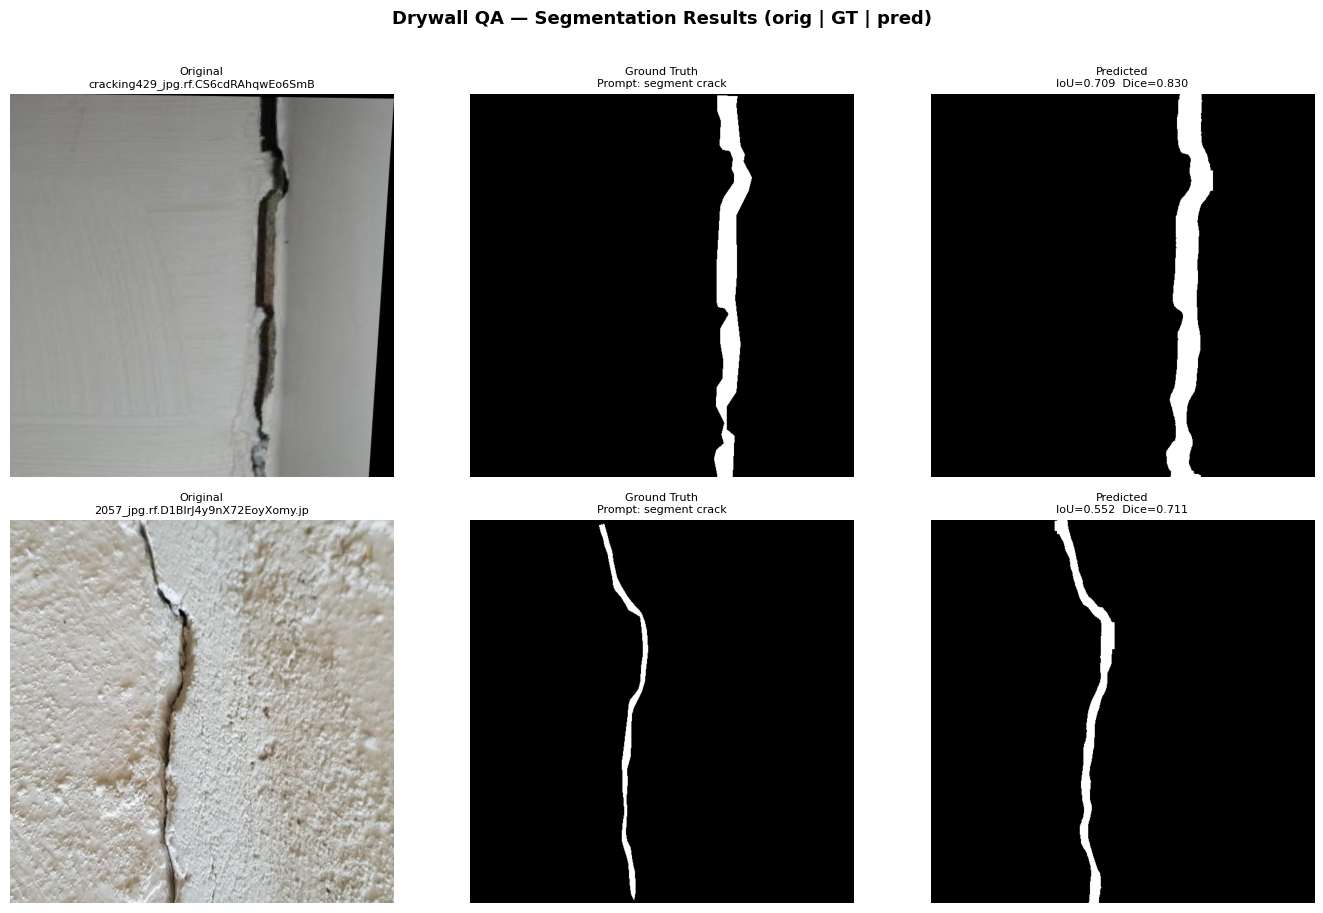

Saved → /content/visual_results.png


In [15]:
random.seed(SEED)

test_imgs = [f for f in sorted(os.listdir(test_img_dir))
             if f.lower().endswith(('.jpg','.jpeg','.png'))]

# Pick 2 images per prompt class for balanced visuals
def pick_samples(prompt_key, class_idx, n=2):
    candidates = []
    for img_name in test_imgs:
        img_id   = os.path.splitext(img_name)[0]
        lbl_path = os.path.join(test_lbl_dir, img_id + '.txt')
        if not os.path.exists(lbl_path): continue
        with open(lbl_path) as f:
            ids = [int(l.split()[0]) for l in f if l.strip()]
        if class_idx in ids:
            candidates.append(img_name)
    return random.sample(candidates, min(n, len(candidates)))

samples = [
    ('segment_taping_area', 0, s) for s in pick_samples('segment_taping_area', 0, 2)
] + [
    ('segment_crack',       1, s) for s in pick_samples('segment_crack', 1, 2)
]

fig, axes = plt.subplots(len(samples), 3, figsize=(14, 4.5 * len(samples)))
if len(samples) == 1: axes = [axes]

for row, (prompt_key, class_idx, img_name) in enumerate(samples):
    img_id   = os.path.splitext(img_name)[0]
    img_bgr  = cv2.imread(os.path.join(test_img_dir, img_name))
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w     = img_bgr.shape[:2]
    lbl_path = os.path.join(test_lbl_dir, img_id + '.txt')

    gt_mask   = yolo_seg_to_mask(lbl_path, h, w, class_idx)
    pred_path = os.path.join(OUTPUT_DIR, f'{img_id}__{prompt_key}.png')
    pred_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE) \
                if os.path.exists(pred_path) else np.zeros((h,w), dtype=np.uint8)
    iou, dice = compute_metrics(pred_mask, gt_mask)

    axes[row][0].imshow(img_rgb)
    axes[row][0].set_title(f'Original\n{img_name[:35]}', fontsize=8)
    axes[row][0].axis('off')

    axes[row][1].imshow(gt_mask, cmap='gray', vmin=0, vmax=255)
    axes[row][1].set_title(f'Ground Truth\nPrompt: {prompt_key.replace("_"," ")}', fontsize=8)
    axes[row][1].axis('off')

    axes[row][2].imshow(pred_mask, cmap='gray', vmin=0, vmax=255)
    axes[row][2].set_title(f'Predicted\nIoU={iou:.3f}  Dice={dice:.3f}', fontsize=8)
    axes[row][2].axis('off')

plt.suptitle('Drywall QA — Segmentation Results (orig | GT | pred)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/visual_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → /content/visual_results.png')

## Cell 12 — Runtime & Footprint Summary

In [12]:
weights_path = '/content/drywall_seg/yoloe26s_run1/weights/best.pt'
model_mb = os.path.getsize(weights_path) / (1024**2)

print('='*48)
print('        RUNTIME & FOOTPRINT SUMMARY')
print('='*48)
print(f'  Model             : YOLOE-26s-seg')
print(f'  Trainer           : YOLOEPESegTrainer')
print(f'  Optimizer         : MuSGD (lr0=0.01)')
print(f'  Epochs            : 50')
print(f'  Image size        : 640x640')
print(f'  Seed              : {SEED}')
print(f'  Model size        : {model_mb:.1f} MB')
print(f'  Training time     : {train_time_mins:.1f} minutes')
print(f'  Avg inference     : {avg_inf_ms:.1f} ms/image')
print('='*48)

        RUNTIME & FOOTPRINT SUMMARY
  Model             : YOLOE-26s-seg
  Trainer           : YOLOEPESegTrainer
  Optimizer         : MuSGD (lr0=0.01)
  Epochs            : 50
  Image size        : 640x640
  Seed              : 42
  Model size        : 22.3 MB
  Training time     : 46.3 minutes
  Avg inference     : 21.9 ms/image
